**Program No. 16.  >> Case Study on Visualization**


**Objective:** To study real-life applications of visualization.


**Tasks:**
- Analyze a small case where visualization improves understanding

**Outcome:** Students will appreciate visualization in real-world decision-making.

**Step 1:** Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2:** Load Dataset

In [2]:
df = pd.read_csv("MMDU_Student_Performance.csv")

df.columns = df.columns.str.strip().str.lower()

# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

# Check data types
print("\nData Types:\n")
print(df.dtypes)

print(df.head())

Missing Values:

11                                     0
bstudent_id                            0
roll_number                            0
registration_number                    0
university_id                          0
                                    ... 
library_usage_frequency                0
lab_access_hours                       0
mentorship_sessions_attended           0
remedial_classes_attended              1
placement_training_participation    1200
Length: 90, dtype: int64

Data Types:

11                                   object
bstudent_id                          object
roll_number                          object
registration_number                  object
university_id                        object
                                     ...   
library_usage_frequency               int64
lab_access_hours                      int64
mentorship_sessions_attended         object
remedial_classes_attended            object
placement_training_participation    float64
Length: 9

**Step 3:** Handle Missing Data Professionally

In [3]:
df_clean = df.dropna(subset=["percentage", "attendance_percentage", "sgpa"])

In [4]:
print(df["percentage"].unique()[:20])

['C' 'B+' 'A' 'A+' 'B' '7.3']


In [5]:
df["total_marks"] = pd.to_numeric(df["total_marks"], errors="coerce")

In [6]:
grade_map = {
    "A+": 90,
    "A": 85,
    "B+": 75,
    "B": 70,
    "C+": 65,
    "C": 60
}

df["percentage_numeric"] = df["percentage"].map(grade_map)

In [7]:
df["percentage_numeric"].mean()

np.float64(76.13844870725605)

In [8]:
df["percentage"] = pd.to_numeric(df["percentage"], errors="coerce")
df["attendance_percentage"] = pd.to_numeric(df["attendance_percentage"], errors="coerce")
df["sgpa"] = pd.to_numeric(df["sgpa"], errors="coerce")

In [9]:
print(df[["percentage","attendance_percentage","sgpa"]].isnull().sum())

percentage               1199
attendance_percentage    1199
sgpa                        1
dtype: int64


In [10]:
df["sgpa"] = pd.to_numeric(df["sgpa"], errors="coerce")
df["attendance_percentage"] = pd.to_numeric(df["attendance_percentage"], errors="coerce")
df["study_hours_per_day"] = pd.to_numeric(df["study_hours_per_day"], errors="coerce")

df = df.dropna(subset=["sgpa", "attendance_percentage"])

**Step 4:** Now Perform Clean Visualization

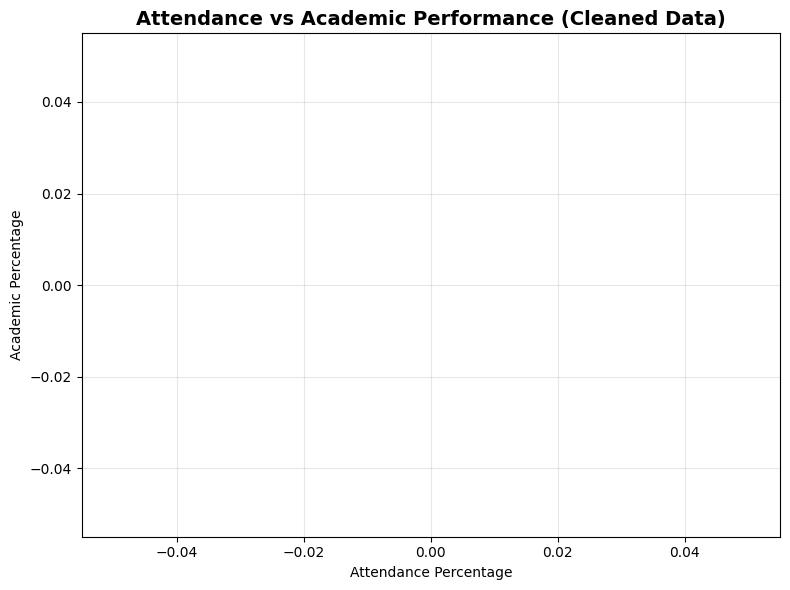

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["attendance_percentage"],
            df["percentage"],
            alpha=0.6)

plt.title("Attendance vs Academic Performance (Cleaned Data)",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Attendance Percentage")
plt.ylabel("Academic Percentage")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Case Question 1** : Does Attendance Affect Performance?

**Visualization 1:** Attendance vs Percentage

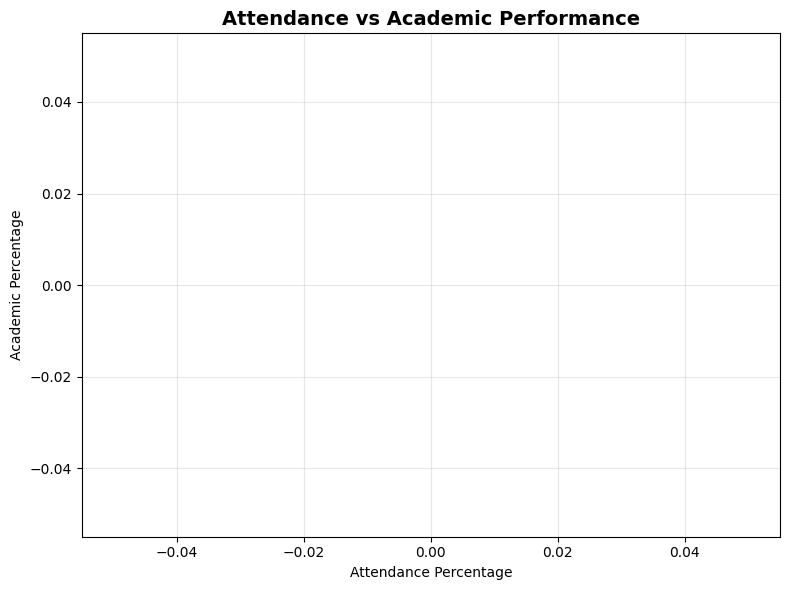

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(df["attendance_percentage"],
            df["percentage"],
            alpha=0.6)

plt.title("Attendance vs Academic Performance",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Attendance Percentage")
plt.ylabel("Academic Percentage")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observation 1**
- Students with higher attendance generally score higher.
- Low attendance cluster shows lower performance.
- Visualization clearly reveals positive relationship.
- Without chart, this pattern is hard to detect from raw data.

**Case Question 2** : Which Department Performs Better?

**Visualization 2:** Department-wise Average Performance

In [13]:
dept_avg = df.groupby("department")["percentage"].mean().sort_values()

plt.figure(figsize=(9,5))

dept_avg.plot(kind="bar")

plt.title("Department-wise Average Percentage",
          fontweight="bold")

plt.xlabel("Department")
plt.ylabel("Average Percentage")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'department'

**Observation 2**
- Departments with lower average percentage are easily identifiable.
- Management can target weak departments.
- Data-driven decision making becomes possible.

**Case Question 3 :** Identify At-Risk Students

**Visualization 3:** Performance Distribution

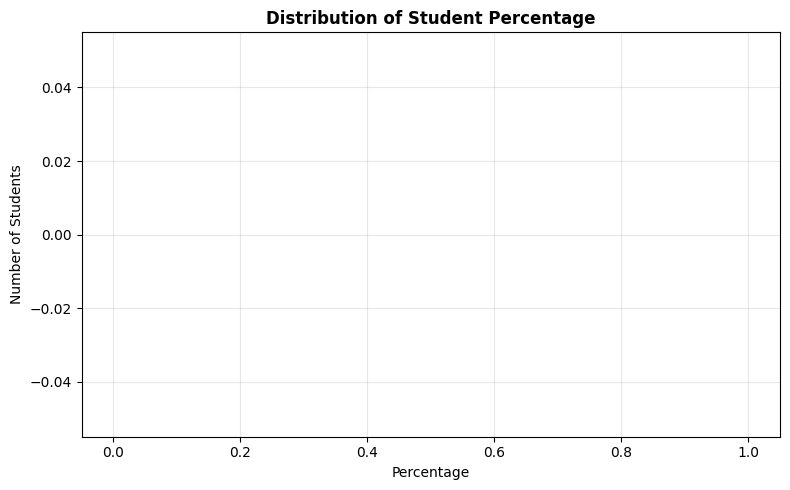

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["percentage"], bins=15)

plt.title("Distribution of Student Percentage",
          fontweight="bold")

plt.xlabel("Percentage")
plt.ylabel("Number of Students")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation 3**
- Students below 50–60% are visible immediately.
- Intervention strategies can be planned.
- Academic risk groups can be identified visually.

This case study demonstrates that visualization transforms raw academic data into actionable insights.

**By using simple charts:**
- Correlations become visible
- Weak areas are identified
- Performance trends are clear
- Data-driven governance becomes possible

Visualization is not just a graph —
It is a decision-support system.